<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Project3/Nikolai_Navarro_Project3_Week14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data 201 Final Project**
## **Nikolai Navarro**
## Spring 2026
---

## **Introduction**
Write a short introduction describing:
- Your dataset
- Your prediction goal
- Why the topic is interesting or important
- Possible limitations or bias in the dataset

Include a citation for your dataset source.

The data set I will be using is titled "Employee Salaries - 2024" and has data collected from Montgomery County Maryland. The data is about the annual salary information including gross pay and overtime pay for all active, permanent employees of Montgomery County, MD paid in calendar year 2024.  It contains information such as department, base salary, overtime pay, longevity pay, and division. The data is realeased every year for the public to view.

This data set contains information from 2024 which is 2 years ago. So its contents may be outdated but not that much. I couldn't find the data set for 2025 salaries. The data may also be incorrect due to human error.

I want to predict the total annual salary an Montgomery County employee makes using variables from the data set such as the department, gender, and base pay, overtime pay, and longevity pay.. I chose this topic because it has data about the salaries in our county and being able to see what how much we are paying employees in the county can help us to create future budgets for county spending in the future.

**Citation:**\
“Employee Salaries - 2024: Open Data Portal.” Employee Salaries - 2024 | Open Data Portal, Montgomery County, 28 Feb. 2025, data.montgomerycountymd.gov/Human-Resources/Employee-Salaries-2024/2nq6-auk8/about_data.

---

## **Dataset and Preparation**

Include:
- Dataset size
- Explanation of variables
- Missing value handling
- Encoding categorical variables if needed
- Train/test split

Include at least one table describing variables.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
import calendar
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df = pd.read_csv("https://raw.githubusercontent.com/Nikolai-N484/Data201_NikolaiN/refs/heads/main/Employee_Salaries_-_2024_20260512.csv")

df.head()

,Department,Department Name,Division,Gender,Base Salary,2024 Overtime Pay,2024 Longevity Pay,Grade
0,ABS,Alcohol Beverage Services,ABS 85 IT Administration,M,"$169,555",$0,$0,M3
1,CUS,Community Use of Public Facilities,CUS 70 Finance and Administrative Support Team,F,"$141,876.93",$0,$0,M3
2,DGS,Department of General Services,DGS 36 Fleet Management Services,F,"$87,523",$748.37,"$2,701.48",16
3,CEX,Offices of the County Executive,CEX 15 Chief Administrative Officer's Office,F,"$207,000",$0,$0,EX2
4,HHS,Department of Health and Human Services,HHS 60 Office of Eligibility and Support Services,F,"$91,392",$0,"$5,733.27",N17


| Column | Description | API Field Name | Data Type |
|:-----|:------:|:------:|------:|
|  Department  |  Department code for the department to which the employee is assigned.  |  department  |  Text  |
|  Department Name  |  Name of the County Department to which the employee is assigned.  |  department_name  |  Text  |
|  Division  |  Name of the division within the County department to which the employee is assigned.  |  division  |  Text  |
|  Gender  |  Gender  |  gender  |  Text  |
|  Base Salary  |  Annual base salary for the employee at the end of the calendar year.  |  base_salary  |  Number  |
|  2024 Overtime Pay  |  Overtime pay the employee received for hours worked beyond the employee’s normally scheduled workday or workweek.  |  _2024_overtime_pay  |  Number  |
|  2024 Longevity Pay  |  Longevity pay the employee received for the length of service in County employment at the end of the calendar year.  |  _2024_longevity_pay  |  Number  |
|  Grade  |  Assigned grade for the employee at the end of the calendar year.  |  grade  |  Text  |

In [136]:
shape = df.shape
print(shape)

(10398, 8)


In [137]:
# Function to clean and convert currency columns to numeric
def clean_currency(col):
    return pd.to_numeric(col.astype(str).str.replace('$', '', regex = False).str.replace(',', '', regex = False))

# Clean Base Salary, 2024 Overtime Pay, and 2024 Longevity Pay columns
df["Base Salary"] = clean_currency(df["Base Salary"])
df["2024 Overtime Pay"] = clean_currency(df["2024 Overtime Pay"])
df["2024 Longevity Pay"] = clean_currency(df["2024 Longevity Pay"])

# Combining base salary and overtime/lengevity pay to get total annual salary
df["Total Salary"] = df["Base Salary"] + df["2024 Overtime Pay"] + df["2024 Longevity Pay"]

#Cleaning Grade columns to extract only the numeric values
df["Grade_Numeric"] = df["Grade"].str.extract(r"(\d+)").astype(float)

df.head()

,Department,Department Name,Division,Gender,Base Salary,2024 Overtime Pay,2024 Longevity Pay,Grade,Total Salary,Grade_Numeric
0,ABS,Alcohol Beverage Services,ABS 85 IT Administration,M,169555.00,0.00,0.00,M3,169555.00,3.0
1,CUS,Community Use of Public Facilities,CUS 70 Finance and Administrative Support Team,F,141876.93,0.00,0.00,M3,141876.93,3.0
2,DGS,Department of General Services,DGS 36 Fleet Management Services,F,87523.00,748.37,2701.48,16,90972.85,16.0
3,CEX,Offices of the County Executive,CEX 15 Chief Administrative Officer's Office,F,207000.00,0.00,0.00,EX2,207000.00,2.0
4,HHS,Department of Health and Human Services,HHS 60 Office of Eligibility and Support Services,F,91392.00,0.00,5733.27,N17,97125.27,17.0


In [138]:
predictor_cols = ["Department", "Division", "Gender", "Grade_Numeric"]

#Dropping rows with NA's if any
df = df.dropna(subset = ["Total Salary"] + predictor_cols)

shape2 = df.shape
print(shape2)

na = df.isna().sum()
print(na)

(10376, 10)
Department            0
Department Name       0
Division              0
Gender                0
Base Salary           0
2024 Overtime Pay     0
2024 Longevity Pay    0
Grade                 0
Total Salary          0
Grade_Numeric         0
dtype: int64


After cleaning the data set, removing any NA's for the variables I plan to use, and creating new variables to create a total annual salary there is a total of 10376 rows and 10 columns.

In [139]:
y = df["Total Salary"]

# Separate categorical and numerical predictor columns
categorical_cols = ["Department", "Division", "Gender"]
numerical_cols = ["Grade_Numeric"]

# Create X by selecting the columns that will be used for modeling
X = df[categorical_cols + numerical_cols]

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns = categorical_cols, drop_first=True)

# Ensure all columns are numeric after encoding
X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce')

# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Features shape: {X_encoded.shape}")
print(f"Target rows: {len(y)}")

Features shape: (10376, 636)
Target rows: 10376


---
## **Exploratory Data Analysis**

Create:
- **2 meaningful visualizations**
- Short interpretations

Discuss:
- Interesting patterns
- Trends
- Possible relationships

Keep this section concise.

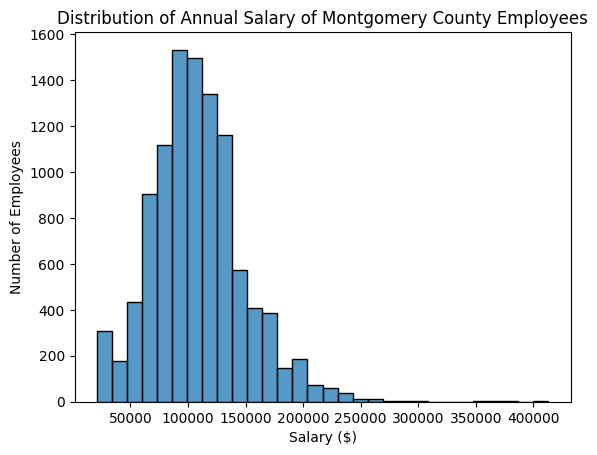

In [140]:
sns.histplot(df["Total Salary"], bins = 30)
plt.xlabel("Salary ($)")
plt.ylabel("Number of Employees")
plt.title("Distribution of Annual Salary of Montgomery County Employees")
plt.show()

The histogram looks roughly normal with a slight right skew. This histogram shows that the average annual salary for Montgomery County employees is between 90k to 120k dollars. A the highest annual salary earned by employee count is about 90k dollars with 1600 employees having that salary.  

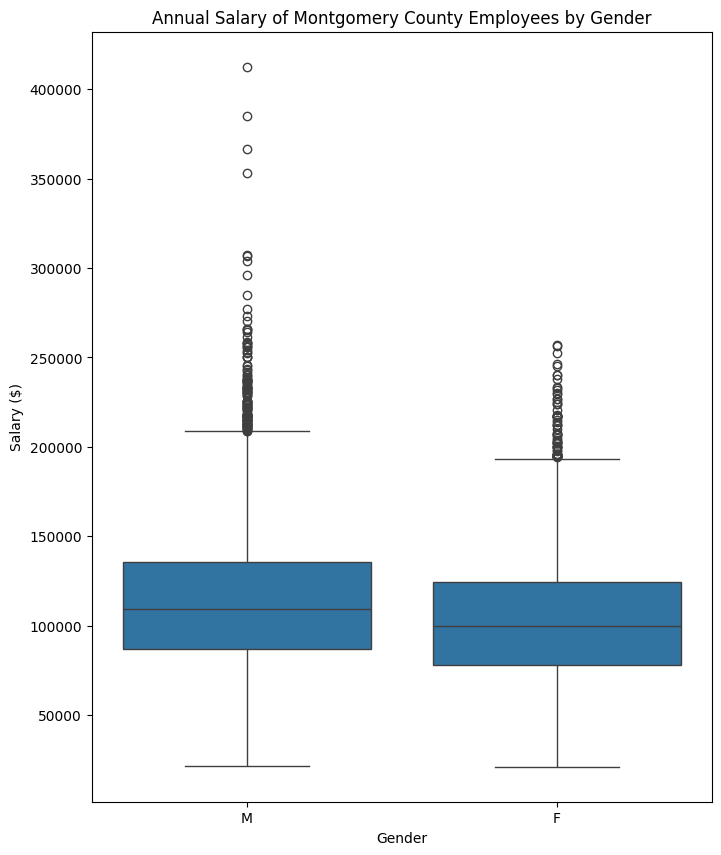

In [141]:
plt.figure(figsize = (8, 10))
sns.boxplot(x = "Gender", y = "Total Salary", data = df)
plt.xlabel("Gender")
plt.ylabel("Salary ($)")
plt.title("Annual Salary of Montgomery County Employees by Gender")
plt.show()

This boxplot shows the distribution of the annual salary of Montgomery County Employees by gender. Both box plots seem to be normally distributed with both having a significant amount of outliers.  It looks like men earn a higher median annual salary at 110k dollars while the womans median annual salary is around 110k dollars. The outlier amounts show that there are many more men that make high amounts of money a year compared to women.

---
## **Decision Tree Analysis (Core Section)**

This is the most important section of the project.

You must:
- Train a Decision Tree Regressor
- Try at least **two different tree depths**
- Briefly discuss possible overfitting
- Include a visualization or diagram of your tree

Also explain:
- The root node
- One important split
- One example prediction path

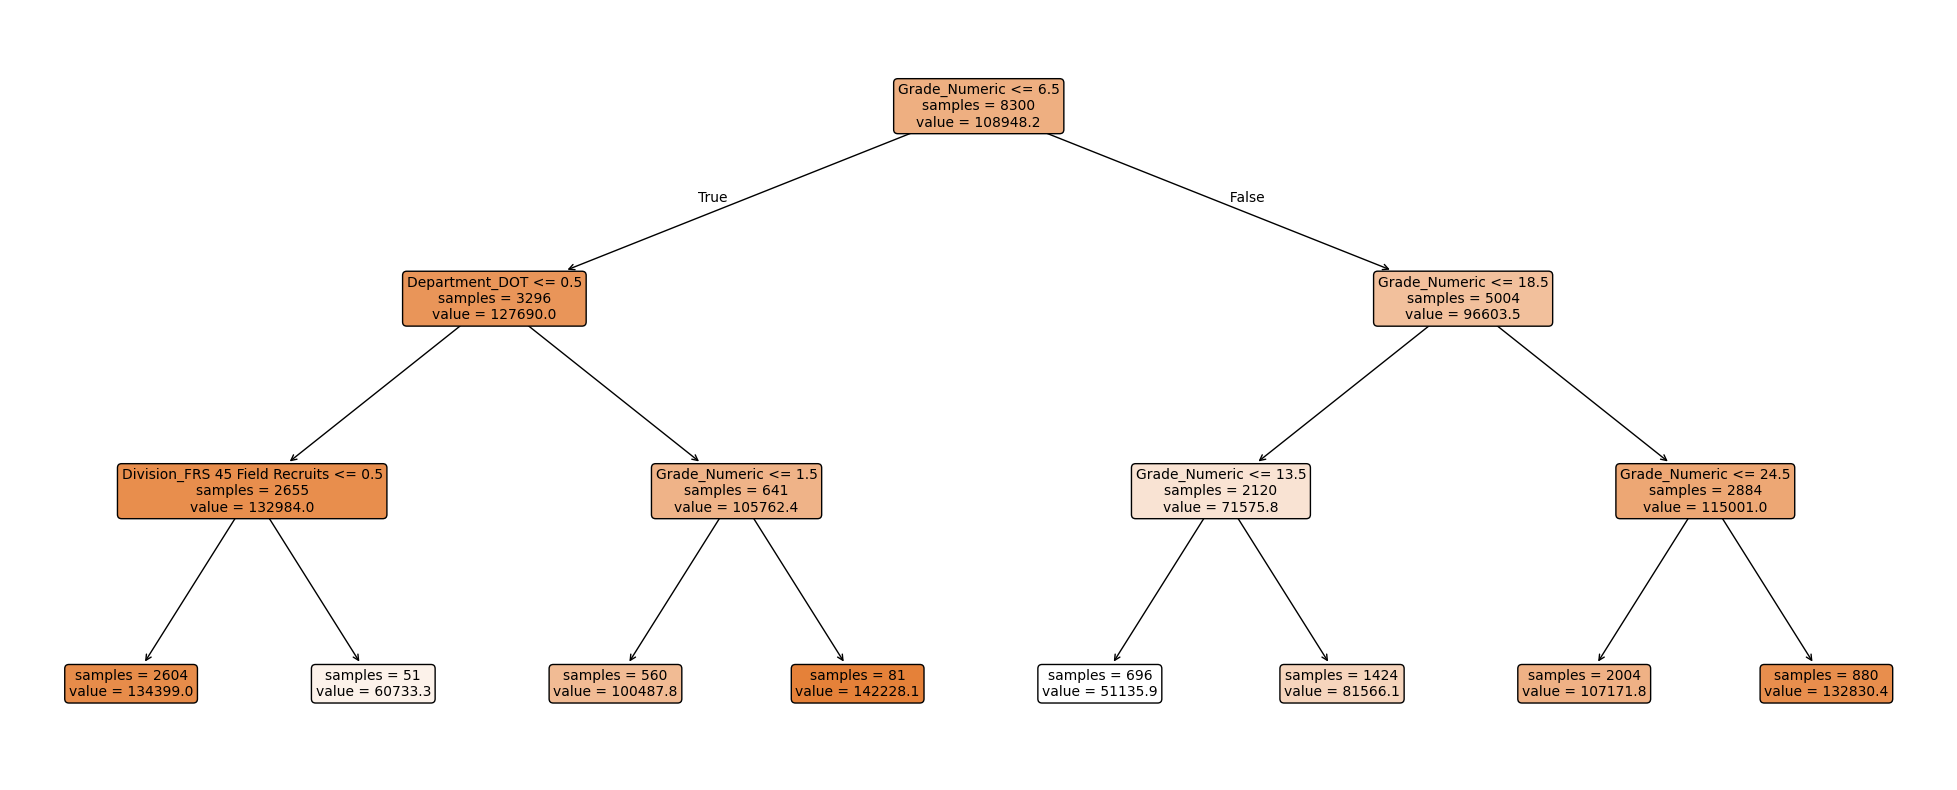

In [142]:
tree_small = DecisionTreeRegressor(max_depth = 3, random_state = 42)

tree_small.fit(X_train, y_train)

plt.figure(figsize = (25, 10))
plot_tree(tree_small, filled = True, feature_names = list(X_train.columns), max_depth = 3, rounded = True, fontsize = 10, precision = 1, impurity = False)
plt.show()

The root node for the decision tree is the assigned grade of the employee which would make sense as an employee with a higher grade would mean that they are in a higher position in to workforce allowing them to earn more money. For example a grade of 5 would be around entry level while a grade of 25 would be department directors.

After the first initial split the data splits again on the left branch by Department DOT seperating employees that work for the department of transportation from the other employees. Then after that split it decides to split by Division FRS which would be employees of fire and rescue services to try and filter throught more employees and make less variance.

One example prediction path would be if someone had a grade that was <= 6.5 and then wasn't in the department of transportation and then had a grade <= 1.5 their predicted annual salary would be 100487.8 dollars.  A total of 560 employees fell into that leaf.

In [143]:
tree_big = DecisionTreeRegressor(max_depth = 6, random_state = 42)

tree_big.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=6, random_state=42)

In [144]:
tree_small_train_r2 = tree_small.score(X_train, y_train)
tree_small_test_r2 = tree_small.score(X_test, y_test)
tree_big_train_r2 = tree_big.score(X_train, y_train)
tree_big_test_r2 = tree_big.score(X_test, y_test)

print(f"Small Tree Train R^2: {tree_small_train_r2:.4f}")
print(f"Small Tree Test R^2: {tree_small_test_r2:.4f}")
print(f"Big Tree Train R^2: {tree_big_train_r2:.4f}")
print(f"Big Tree Test R^2: {tree_big_test_r2:.4f}")

Small Tree Train R^2: 0.4397
Small Tree Test R^2: 0.4381
Big Tree Train R^2: 0.5434
Big Tree Test R^2: 0.5241


Looking at the small tree models r-squared it has a training r^2 of 0.4397 and a testing r^2 of 0.4381. This shows that the model is able to generalize well as it performs identically on the data it learned from and the unknown data with only a 0.0016 difference between the r-squares. However, it only explains 43.81% of the variation of annual salary. This could be because the model had too little splits and the depth was too small limiting the models ability to learn from the data. The model is not overfitting.

Looking at the big tree model r-squared it has a training r^2 of 0.5434 and a testing r-square of 0.5241. This shows that the descision tree model  is also able to generalize well as it performs identically on the data it learned from and the unknown data with only a 0.0193 difference between the r-squares. This model doesn't seem like it is overfitting.

Although, the big tree model has a higher training-test r^2 gap I still believe it performs better than the small tree model. This is because it is able to explain 52.41% of the variance of annual salary which is more than what the small tree model was able to explain.

An overfitting model will begin to memorize specific noise from the data set and doesn't allow the model to capture the underlying pattern. But both small tree and big tree models are not overfitting.

---
## **Ensemble Models**

Train:
- Random Forest
- Gradient Boosting

Compare them to your single decision tree.

Discuss:
- Did performance improve?
- Which model generalized better?
- Which model was easier to explain?

You are NOT expected to perform advanced hyperparameter tuning.

In [145]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingRegressor(n_estimators = 100, random_state = 42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [146]:
mse_rf = mean_squared_error(y_test, rf_model.predict(X_test))
mse_gb = mean_squared_error(y_test, gb_model.predict(X_test))

test_r2_rf = r2_score(y_test, rf_model.predict(X_test))
train_r2_rf = r2_score(y_train, rf_model.predict(X_train))
test_r2_gb = r2_score(y_test, gb_model.predict(X_test))
train_r2_gb = r2_score(y_train, gb_model.predict(X_train))

print(f"Random Forest RMSE: {np.sqrt(mse_rf):.2f}")
print(f"Random Forest R^2: {test_r2_rf:.4f}")
print(f"Gradient Boosting RMSE: {np.sqrt(mse_gb):.2f}")
print(f"Gradient Boosting R^2: {test_r2_gb:.4f}")

Random Forest RMSE: 24385.35
Random Forest R^2: 0.6196
Gradient Boosting RMSE: 26807.34
Gradient Boosting R^2: 0.5402


In [147]:
mse_dt = mean_squared_error(y_test, tree_big.predict(X_test))
r2_dt = r2_score(y_test, tree_big.predict(X_test))

print(f"Decision Tree RMSE: {np.sqrt(mse_dt):.2f}")
print(f"Decision Tree R^2: {r2_dt:.4f}")

Decision Tree RMSE: 27273.25
Decision Tree R^2: 0.5241


Comparing both the random forest model and the gradient boosting model to the the big decision tree model both the random forest model and the gradient boosting model seemed to have performed better. This is due to both models having a lower RMSE and higher r-squared when compared to the original decision tree. Overall I believe the random forest model performed the best and was able to generalize better as it had the lowest rmse of 24385.35 and the highest r^2 of 0.6196 which means it was able to explain 61.96% of the variance of annual salaries. The model that will be easiest to explain though would be the single big decision tree model as it only has one tree allowing it to be interpreted easier while the random forest has multiple trees and gradient boosting is usually less interpretable.

---
## **Model Evaluation**

You must include:

| Metric | Meaning |
|---|---|
| MSE | Lower is better |
| \(R^2\) | Higher is better |

Include:
- A comparison table
- Actual vs Predicted visualization
- Short interpretation of results

| Model | Root Mean Square Error (Lower better) | R2 (Higher better) | Performance |
|:-----|:------:|:------:|-----:|
|  Decision Tree  |  *27273.25*  |  *0.5241*  | Third |
|  Random forest  |  **24385.35**  |  **0.6196**  | First |
|  Gradient Boosting  |  26807.34  |  0.5402  | Second |

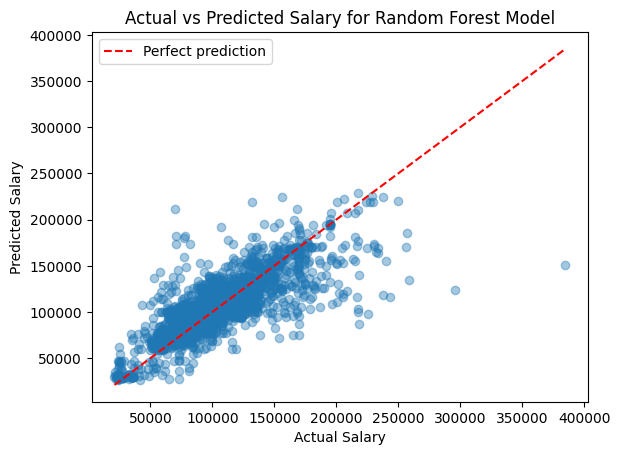

In [148]:
plt.scatter(y_test, rf_model.predict(X_test), alpha = 0.4)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle = "--", color = "red", label = "Perfect prediction")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary for Random Forest Model")
plt.legend()

---
## **Feature Importance**

For at least one ensemble model:
- Display feature importance
- Identify the top 3 most important features

Important:
- Feature importance does NOT prove causation

Top 3 Most Important Features: for Predicting Annual Salary
           Feature  Importance
0    Grade_Numeric    0.592264
12  Department_DOT    0.036204
36  Department_POL    0.025355


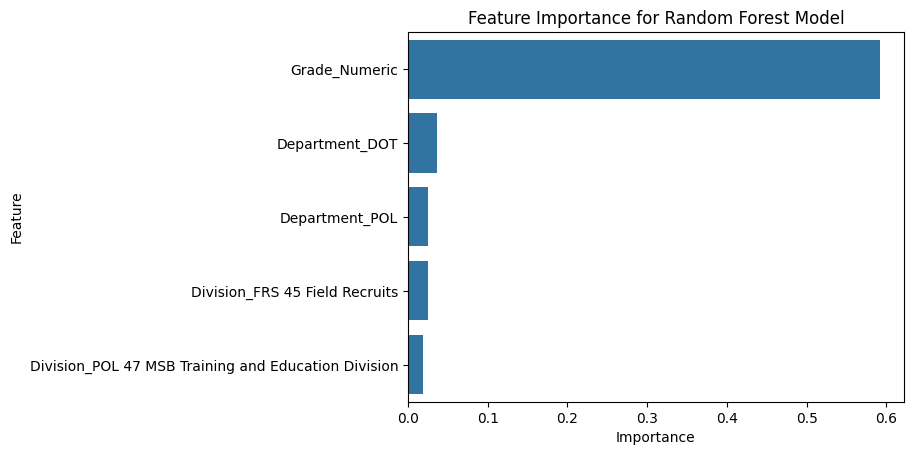

In [153]:
Importance = rf_model.feature_importances_
feature_names = X_encoded.columns

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': Importance})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

# Display the top 3 most important features
top_3_features = feature_importance_df.head(3)
print("Top 3 Most Important Features: for Predicting Annual Salary")
print(top_3_features)

sns.barplot(x = "Importance", y = "Feature", data = feature_importance_df)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Random Forest Model")
plt.show()

---
## **Final Reflection: The Model Battle**

Answer the following questions:

1. Which model performed best?
2. Which model was easiest to explain?
3. Which model would you choose in a real-world setting and why?